# Day13 Regression using Logistics Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df=pd.read_csv('global_supply_chain_risk_2026.csv')
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [3]:
df=df.drop(columns=['Shipment_ID','Date'])
le=LabelEncoder()
for c in df.columns:
    if df[c].dtype=='object':
        df[c]=le.fit_transform(df[c])
X=df.drop('Lead_Time_Days',axis=1)
y=df['Lead_Time_Days']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)

In [5]:
pd.DataFrame({'Actual':y_test.values,'Predicted':pred}).head(10)

,Actual,Predicted
0,17.43,43.733465
1,21.78,26.778254
2,1.58,-6.725374
3,6.40,24.894000
4,1.74,9.708395
5,9.61,20.767515
6,0.88,-5.533744
7,46.56,45.780364
8,0.50,2.836473
9,2.86,-8.151266


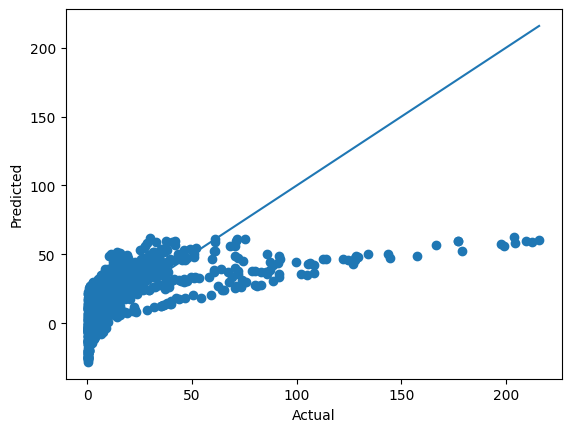

In [6]:
plt.scatter(y_test,pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

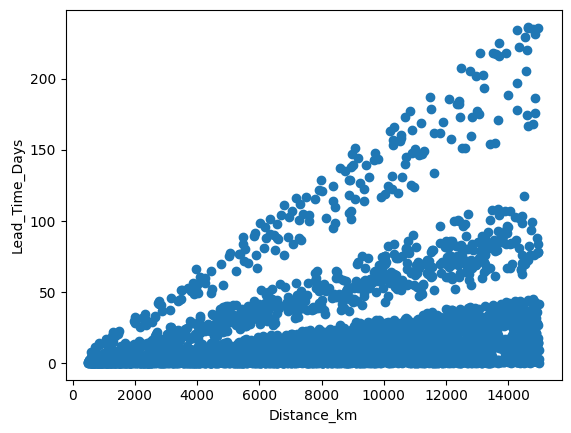

In [7]:
feat='Distance_km'
simple=LinearRegression()
simple.fit(X_train[[feat]],y_train)
plt.scatter(X_train[feat],y_train)
plt.plot(X_train[feat],simple.predict(X_train[[feat]]))
plt.xlabel(feat);plt.ylabel('Lead_Time_Days')
plt.show()

In [8]:
print('Slope:',simple.coef_[0])
print('Intercept:',simple.intercept_)
print(f'Equation: y = {simple.coef_[0]:.4f}x + {simple.intercept_:.4f}')

Slope: 0.00256201648061991
Intercept: -0.20904873307593164
Equation: y = 0.0026x + -0.2090


In [9]:
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
r2=r2_score(y_test,pred)
print(mae,mse,r2)

15.914641371067823 595.2134337495381 0.34070574413327326


In [10]:
new=X.iloc[:3]
print(model.predict(new))

[16.83780738 41.67182441 14.72558939]


In [11]:
print('Performance')
print('MAE',mae)
print('MSE',mse)
print('R2',r2)
if r2>0.9: print('Best')
elif r2>0.75: print('Good')
else: print('Needs Improvement')

Performance
MAE 15.914641371067823
MSE 595.2134337495381
R2 0.34070574413327326
Needs Improvement


## Theory
1. Regression predicts continuous values.
2. Linear Regression models a linear relationship between features and target.
3. MAE measures average absolute error.
4. MSE penalizes large errors more heavily.
5. R² close to 1 means an excellent fit.